# Training HAR — Body110 + CNN-BiLSTM + Partial-Prefix Learning

Model tetap mengeluarkan sembilan kelas. Pembaruan ini mengajarkan model untuk mengenali aktivitas dari sebagian frame awal, lalu mengukur kapan prediksi dini cukup layak digunakan.


## 1. Instalasi dependency

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "onnx": "onnx",
    "onnxruntime": "onnxruntime",
    "sklearn": "scikit-learn",
}

missing = [
    pip_name
    for module_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *missing,
    ])

print("Dependency siap.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 37.0 MB/s eta 0:00:00
Dependency siap.


## 2. Import

In [2]:
from __future__ import annotations

import copy
import hashlib
import json
import math
import os
import random
import re
import shutil
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight
from torch.nn.utils import clip_grad_norm_

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## 3. Konfigurasi final

In [3]:
KAGGLE_INPUT_ROOT = Path("/kaggle/input")
KAGGLE_WORKING_ROOT = Path("/kaggle/working")

OUTPUT_ROOT = (
    KAGGLE_WORKING_ROOT
    / "TRAINING_FINAL_BODY110_SEEDS_42_123_3407_2024_2025"
)

MODEL_DIR = OUTPUT_ROOT / "models"
REPORT_DIR = OUTPUT_ROOT / "reports"
PLOT_DIR = OUTPUT_ROOT / "plots"

for folder in [
    OUTPUT_ROOT,
    MODEL_DIR,
    REPORT_DIR,
    PLOT_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

WINDOW_SIZE = 30
TARGET_FPS = 30.0

# Training masih memakai tensor sepanjang 30 frame. Pada sebagian batch,
# hanya prefix awal yang diperlihatkan dan sisanya dibuat padding.
# Ini mengajarkan kondisi real-time saat track belum mencapai 30 frame.
USE_PARTIAL_PREFIX_AUGMENTATION = True
PARTIAL_PREFIX_PROBABILITY = 0.50
PARTIAL_PREFIX_LENGTHS = (8, 12, 16, 20, 24, 30)
MIN_VALID_FRAMES_FOR_PARTIAL = 6

# Setelah training, jumlah frame minimum dipilih memakai validation set.
PREFIX_EVAL_LENGTHS = PARTIAL_PREFIX_LENGTHS
PREFIX_MIN_F1_RATIO = 0.90
PREFIX_MIN_COVERAGE = 0.80

NUM_KEYPOINTS = 17
NUM_CLASSES = 9

RAW_FEATURES_PER_KEYPOINT = 3
MODEL_FEATURES_PER_KEYPOINT = 5

RAW_FEATURE_DIM = (
    NUM_KEYPOINTS
    * RAW_FEATURES_PER_KEYPOINT
)

BASE_MOTION_FEATURE_DIM = (
    NUM_KEYPOINTS
    * MODEL_FEATURES_PER_KEYPOINT
)

ENGINEERED_FEATURE_DIM = 25

MODEL_FEATURE_DIM = (
    BASE_MOTION_FEATURE_DIM
    + ENGINEERED_FEATURE_DIM
)

BODY85_DIM = BASE_MOTION_FEATURE_DIM
BODY110_DIM = MODEL_FEATURE_DIM

assert RAW_FEATURE_DIM == 51
assert BODY85_DIM == 85
assert BODY110_DIM == 110

SEEDS = [42, 123, 3407, 2024, 2025]
BATCH_SIZE = 64
NUM_WORKERS = 0
MAX_EPOCHS = 80

EMBEDDING_DIM = 128
CNN_DIM_1 = 128
CNN_DIM_2 = 160
LSTM_HIDDEN = 128

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 3e-4
MIN_LR = 1e-6
GRAD_CLIP_NORM = 1.0
LABEL_SMOOTHING = 0.01

EARLY_STOPPING_PATIENCE = 15
LR_PATIENCE = 5
LR_FACTOR = 0.5

USE_AMP = True
USE_CLASS_WEIGHT = True

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device :", DEVICE)
print("Output :", OUTPUT_ROOT)

print("Partial-prefix training:", USE_PARTIAL_PREFIX_AUGMENTATION)
print("Candidate prefixes     :", PARTIAL_PREFIX_LENGTHS)


Device : cuda
Output : /kaggle/working/TRAINING_FINAL_BODY110_SEEDS_42_123_3407_2024_2025
Partial-prefix training: True
Candidate prefixes     : (8, 12, 16, 20, 24, 30)


## 4. Tentukan folder hasil preprocessing low-motion

In [4]:
# ============================================================
# PATH DATASET HASIL LOW-MOTION FILTER
# ============================================================

PREPROCESSED_ROOT = Path(
    "/kaggle/input/datasets/wafabila/preprocessing-low-motion"
)

ARRAY_DIR = PREPROCESSED_ROOT / "arrays"

REQUIRED_ARRAYS = [
    "X_sequences.npy",
    "y_labels.npy",
    "valid_masks.npy",
    "source_video_ids.npy",
    "sequence_ids.npy",
    "splits.npy",
    "train_indices.npy",
    "validation_indices.npy",
    "test_indices.npy",
]

if not PREPROCESSED_ROOT.exists():
    raise FileNotFoundError(
        "Folder preprocessing tidak ditemukan:\n"
        f"{PREPROCESSED_ROOT}"
    )

if not ARRAY_DIR.exists():
    raise FileNotFoundError(
        "Folder arrays tidak ditemukan:\n"
        f"{ARRAY_DIR}"
    )

missing_arrays = [
    filename
    for filename in REQUIRED_ARRAYS
    if not (ARRAY_DIR / filename).exists()
]

if missing_arrays:
    raise FileNotFoundError(
        "File array belum lengkap:\n"
        + "\n".join(
            f"- {filename}"
            for filename in missing_arrays
        )
    )

class_mapping_path = (
    PREPROCESSED_ROOT
    / "class_mapping.json"
)

if not class_mapping_path.exists():
    raise FileNotFoundError(
        "class_mapping.json tidak ditemukan:\n"
        f"{class_mapping_path}"
    )

print("Preprocessing final ditemukan:")
print("- Root         :", PREPROCESSED_ROOT)
print("- Arrays       :", ARRAY_DIR)
print("- Class mapping:", class_mapping_path)
print("- Status       : LENGKAP")


Preprocessing final ditemukan:
- Root         : /kaggle/input/datasets/wafabila/preprocessing-low-motion
- Arrays       : /kaggle/input/datasets/wafabila/preprocessing-low-motion/arrays
- Class mapping: /kaggle/input/datasets/wafabila/preprocessing-low-motion/class_mapping.json
- Status       : LENGKAP


## 5. Reproducibility

In [5]:
def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Lebih reproducible antar-run.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    try:
        torch.use_deterministic_algorithms(
            True,
            warn_only=True,
        )
    except Exception:
        pass


print("Seeds eksperimen:", SEEDS)

Seeds eksperimen: [42, 123, 3407, 2024, 2025]


## 6. Load class mapping dan dataset

In [6]:
def load_class_mapping(path: Path):
    with path.open(
        "r",
        encoding="utf-8",
    ) as file:
        raw_mapping = json.load(file)

    if all(
        isinstance(value, int)
        for value in raw_mapping.values()
    ):
        class_to_index = {
            str(key): int(value)
            for key, value
            in raw_mapping.items()
        }

        index_to_class = {
            value: key
            for key, value
            in class_to_index.items()
        }
    else:
        index_to_class = {
            int(key): str(value)
            for key, value
            in raw_mapping.items()
        }

        class_to_index = {
            value: key
            for key, value
            in index_to_class.items()
        }

    class_names = [
        index_to_class[index]
        for index in range(
            len(index_to_class)
        )
    ]

    return (
        class_to_index,
        index_to_class,
        class_names,
    )


(
    class_to_index,
    index_to_class,
    class_names,
) = load_class_mapping(
    PREPROCESSED_ROOT
    / "class_mapping.json"
)

X_raw = np.load(
    ARRAY_DIR / "X_sequences.npy"
).astype(np.float32)

y = np.load(
    ARRAY_DIR / "y_labels.npy"
).astype(np.int64)

valid_masks = np.load(
    ARRAY_DIR / "valid_masks.npy"
).astype(bool)

source_video_ids = np.asarray(
    np.load(
        ARRAY_DIR
        / "source_video_ids.npy",
        allow_pickle=True,
    ),
    dtype=str,
)

sequence_ids = np.asarray(
    np.load(
        ARRAY_DIR
        / "sequence_ids.npy",
        allow_pickle=True,
    ),
    dtype=str,
)

splits = np.asarray(
    np.load(
        ARRAY_DIR / "splits.npy",
        allow_pickle=True,
    ),
    dtype=str,
)

train_idx = np.load(
    ARRAY_DIR / "train_indices.npy"
).astype(np.int64)

val_idx = np.load(
    ARRAY_DIR
    / "validation_indices.npy"
).astype(np.int64)

test_idx = np.load(
    ARRAY_DIR / "test_indices.npy"
).astype(np.int64)

assert X_raw.shape[1:] == (
    WINDOW_SIZE,
    RAW_FEATURE_DIM,
)

assert len(class_names) == NUM_CLASSES

assert (
    len(X_raw)
    == len(y)
    == len(valid_masks)
    == len(source_video_ids)
    == len(sequence_ids)
    == len(splits)
)

train_videos = set(
    source_video_ids[train_idx]
)
val_videos = set(
    source_video_ids[val_idx]
)
test_videos = set(
    source_video_ids[test_idx]
)

assert not (
    train_videos & val_videos
    or train_videos & test_videos
    or val_videos & test_videos
), "Source-video leakage ditemukan."

print("X shape       :", X_raw.shape)
print("Train         :", len(train_idx))
print("Validation    :", len(val_idx))
print("Test          :", len(test_idx))
print("Train videos  :", len(train_videos))
print("Val videos    :", len(val_videos))
print("Test videos   :", len(test_videos))
print("Classes       :", class_names)

X shape       : (27441, 30, 51)
Train         : 20629
Validation    : 4034
Test          : 2778
Train videos  : 749
Val videos    : 147
Test videos   : 100
Classes       : ['boxing', 'carrying', 'clapping', 'digging', 'jogging', 'running', 'throwing', 'walking', 'waving']


## 7. Feature engineering body110

### Penjelasan Body110 dan 25 fitur tambahan

Body110 bukan kumpulan aturan seperti `if sudut siku < ... maka boxing`. Model tetap mempelajari pola dari data berlabel. Angka 110 berasal dari **85 fitur dasar + 25 fitur biomekanik**.

| Kelompok | Jumlah | Isi | Kegunaan intuitif |
|---|---:|---|---|
| Sudut siku | 4 | sudut siku kiri/kanan dan perubahannya | membantu membaca tekuk-lurus lengan |
| Ekstensi lengan | 4 | jarak wrist–shoulder dan perubahannya | membedakan lengan menetap dan menjulur |
| Kecepatan tangan | 6 | besar, horizontal, dan vertikal kiri/kanan | membaca arah serta intensitas gerak tangan |
| Hubungan dua tangan | 6 | jarak, perubahan jarak, selisih kecepatan, simetri, oposisi, sinkroni | membantu pola clapping, boxing, carrying, dan waving |
| Pusat tubuh dan kaki | 5 | gerak hip/shoulder, gerak ankle, lebar langkah | membantu walking, jogging, running, dan digging |

Contoh: boxing biasanya memperlihatkan perubahan sudut siku dan ekstensi tangan berulang; running mempunyai gerak pusat tubuh serta kaki yang lebih cepat daripada walking. Namun keputusan final tetap dihasilkan CNN-BiLSTM dari kombinasi seluruh fitur sepanjang waktu, bukan dari satu threshold buatan tangan.


In [7]:
# ============================================================
# BODY-RELATIVE KNOWLEDGE-GUIDED FEATURE ENGINEERING V2
#
# Posisi:
#   relatif terhadap pusat tubuh dan dinormalisasi panjang torso.
#
# Velocity:
#   tetap dihitung dari frame_xy agar gerak global tidak hilang.
#
# Tujuan:
#   mengurangi shortcut posisi absolut dan membedakan
#   boxing dari digging melalui pola ekstensi lengan.
# ============================================================

LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
LEFT_ELBOW = 7
RIGHT_ELBOW = 8
LEFT_WRIST = 9
RIGHT_WRIST = 10
LEFT_HIP = 11
RIGHT_HIP = 12
LEFT_KNEE = 13
RIGHT_KNEE = 14
LEFT_ANKLE = 15
RIGHT_ANKLE = 16

BODY_RELATIVE_CLIP = 4.0
MIN_BODY_SCALE = 0.03


ENGINEERED_FEATURE_NAMES = [
    "left_elbow_angle",
    "right_elbow_angle",
    "left_elbow_angular_velocity",
    "right_elbow_angular_velocity",

    "left_wrist_to_shoulder",
    "right_wrist_to_shoulder",
    "left_arm_extension_velocity",
    "right_arm_extension_velocity",

    "left_wrist_relative_speed",
    "right_wrist_relative_speed",
    "left_wrist_relative_horizontal_speed",
    "right_wrist_relative_horizontal_speed",
    "left_wrist_relative_vertical_speed",
    "right_wrist_relative_vertical_speed",

    "wrist_distance",
    "wrist_distance_change",
    "hand_speed_difference",
    "hand_motion_symmetry",

    "extension_opposition",
    "extension_synchrony",

    "hip_center_speed",
    "shoulder_center_speed",
    "left_ankle_relative_speed",
    "right_ankle_relative_speed",
    "stride_width",
]

assert len(
    ENGINEERED_FEATURE_NAMES
) == ENGINEERED_FEATURE_DIM


def safe_angle(
    a,
    b,
    c,
    valid_a,
    valid_b,
    valid_c,
):
    """Sudut A-B-C dalam skala 0 sampai 1."""
    ba = a - b
    bc = c - b

    norm_ba = np.linalg.norm(
        ba,
        axis=-1,
    )
    norm_bc = np.linalg.norm(
        bc,
        axis=-1,
    )

    valid = (
        valid_a
        & valid_b
        & valid_c
        & (norm_ba > 1e-6)
        & (norm_bc > 1e-6)
    )

    denominator = np.maximum(
        norm_ba * norm_bc,
        1e-6,
    )

    cosine = (
        np.sum(
            ba * bc,
            axis=-1,
        )
        / denominator
    )

    angle = np.arccos(
        np.clip(
            cosine,
            -1.0,
            1.0,
        )
    ) / np.pi

    return np.where(
        valid,
        angle,
        0.0,
    ).astype(np.float32)


def safe_distance(
    a,
    b,
    valid_a,
    valid_b,
):
    distance = np.linalg.norm(
        a - b,
        axis=-1,
    )

    return np.where(
        valid_a & valid_b,
        distance,
        0.0,
    ).astype(np.float32)


def safe_speed(
    velocity,
    valid,
):
    speed = np.linalg.norm(
        velocity,
        axis=-1,
    )

    return np.where(
        valid,
        speed,
        0.0,
    ).astype(np.float32)


def temporal_signed_difference(
    values,
    valid,
):
    """
    value[t] - value[t-1].

    Nilai positif pada jarak wrist-shoulder berarti
    lengan sedang menjulur/ekstensi.
    """
    output = np.zeros_like(
        values,
        dtype=np.float32,
    )

    pair_valid = (
        valid[:, 1:]
        & valid[:, :-1]
    )

    output[:, 1:] = np.where(
        pair_valid,
        values[:, 1:]
        - values[:, :-1],
        0.0,
    )

    return output.astype(np.float32)


def temporal_absolute_difference(
    values,
    valid,
):
    return np.abs(
        temporal_signed_difference(
            values,
            valid,
        )
    ).astype(np.float32)


def motion_symmetry(
    left_velocity,
    right_velocity,
    valid_left,
    valid_right,
):
    """
    Kesamaan arah gerak tangan kiri dan kanan.

    0   : berlawanan atau tidak valid
    0.5 : tegak lurus
    1   : searah
    """
    left_norm = np.linalg.norm(
        left_velocity,
        axis=-1,
    )

    right_norm = np.linalg.norm(
        right_velocity,
        axis=-1,
    )

    valid = (
        valid_left
        & valid_right
        & (left_norm > 1e-6)
        & (right_norm > 1e-6)
    )

    cosine = (
        np.sum(
            left_velocity
            * right_velocity,
            axis=-1,
        )
        / np.maximum(
            left_norm * right_norm,
            1e-6,
        )
    )

    cosine = np.clip(
        cosine,
        -1.0,
        1.0,
    )

    normalized = (
        cosine + 1.0
    ) / 2.0

    return np.where(
        valid,
        normalized,
        0.0,
    ).astype(np.float32)


def calculate_body_center_and_scale(
    xy,
    valid,
):
    """
    Menghasilkan pusat tubuh dan skala torso untuk setiap frame.

    Prioritas pusat:
    1. midpoint kedua hip;
    2. midpoint kedua shoulder;
    3. rata-rata seluruh keypoint valid.

    Prioritas skala:
    1. jarak shoulder-center ke hip-center;
    2. lebar shoulder;
    3. lebar hip;
    4. nilai minimum aman.
    """
    left_hip_valid = valid[..., LEFT_HIP]
    right_hip_valid = valid[..., RIGHT_HIP]
    left_shoulder_valid = valid[..., LEFT_SHOULDER]
    right_shoulder_valid = valid[..., RIGHT_SHOULDER]

    both_hips_valid = (
        left_hip_valid
        & right_hip_valid
    )

    both_shoulders_valid = (
        left_shoulder_valid
        & right_shoulder_valid
    )

    hip_center = (
        xy[..., LEFT_HIP, :]
        + xy[..., RIGHT_HIP, :]
    ) / 2.0

    shoulder_center = (
        xy[..., LEFT_SHOULDER, :]
        + xy[..., RIGHT_SHOULDER, :]
    ) / 2.0

    valid_count = np.maximum(
        valid.sum(
            axis=-1,
            keepdims=True,
        ),
        1,
    )

    valid_mean = (
        (
            xy
            * valid[..., None]
        ).sum(axis=-2)
        / valid_count
    )

    center = np.where(
        both_hips_valid[..., None],
        hip_center,
        np.where(
            both_shoulders_valid[..., None],
            shoulder_center,
            valid_mean,
        ),
    )

    torso_valid = (
        both_hips_valid
        & both_shoulders_valid
    )

    torso_length = np.linalg.norm(
        shoulder_center
        - hip_center,
        axis=-1,
    )

    shoulder_width = np.linalg.norm(
        xy[..., LEFT_SHOULDER, :]
        - xy[..., RIGHT_SHOULDER, :],
        axis=-1,
    )

    hip_width = np.linalg.norm(
        xy[..., LEFT_HIP, :]
        - xy[..., RIGHT_HIP, :],
        axis=-1,
    )

    scale = np.where(
        torso_valid
        & (torso_length > MIN_BODY_SCALE),
        torso_length,
        np.where(
            both_shoulders_valid
            & (shoulder_width > MIN_BODY_SCALE),
            shoulder_width,
            np.where(
                both_hips_valid
                & (hip_width > MIN_BODY_SCALE),
                hip_width,
                MIN_BODY_SCALE,
            ),
        ),
    )

    scale = np.maximum(
        scale,
        MIN_BODY_SCALE,
    ).astype(np.float32)

    return (
        center.astype(np.float32),
        scale.astype(np.float32),
    )


def build_base_motion_features(
    raw: np.ndarray,
) -> np.ndarray:
    """
    Input:
        (N, T, 51) frame_xy.

    Output:
        (N, T, 85), yaitu per keypoint:
        relative_x, relative_y, confidence, frame_dx, frame_dy.

    Posisi relatif mengurangi ketergantungan terhadap lokasi
    orang di frame. Velocity frame_xy tetap menyimpan informasi
    perpindahan global untuk walking, jogging, dan running.
    """
    if (
        raw.ndim != 3
        or raw.shape[-1]
        != RAW_FEATURE_DIM
    ):
        raise ValueError(
            f"Shape raw salah: {raw.shape}"
        )

    n, t, _ = raw.shape

    pose = raw.reshape(
        n,
        t,
        NUM_KEYPOINTS,
        RAW_FEATURES_PER_KEYPOINT,
    )

    frame_xy = pose[..., :2]
    conf = pose[..., 2:3]
    valid = conf[..., 0] > 0

    center, body_scale = (
        calculate_body_center_and_scale(
            frame_xy,
            valid,
        )
    )

    relative_xy = (
        frame_xy
        - center[..., None, :]
    ) / body_scale[..., None, None]

    relative_xy = np.clip(
        relative_xy,
        -BODY_RELATIVE_CLIP,
        BODY_RELATIVE_CLIP,
    )

    relative_xy[
        ~valid
    ] = 0.0

    frame_displacement = np.zeros_like(
        frame_xy,
        dtype=np.float32,
    )

    pair_valid = (
        valid[:, 1:]
        & valid[:, :-1]
    )

    frame_displacement[:, 1:] = (
        frame_xy[:, 1:]
        - frame_xy[:, :-1]
    ) * pair_valid[..., None]

    base = np.concatenate(
        [
            relative_xy,
            conf,
            frame_displacement,
        ],
        axis=-1,
    )

    output = base.reshape(
        n,
        t,
        BASE_MOTION_FEATURE_DIM,
    ).astype(np.float32)

    if not np.isfinite(
        output
    ).all():
        raise RuntimeError(
            "Base feature mengandung NaN atau Inf."
        )

    return output


def append_engineered_features(
    base_motion: np.ndarray,
) -> np.ndarray:
    """
    Menambahkan 25 fitur biomekanik V2.

    Input:
        (N, T, 85)

    Output:
        (N, T, 110)
    """
    if (
        base_motion.ndim != 3
        or base_motion.shape[-1]
        != BASE_MOTION_FEATURE_DIM
    ):
        raise ValueError(
            "Shape base motion salah: "
            f"{base_motion.shape}"
        )

    pose = base_motion.reshape(
        *base_motion.shape[:2],
        NUM_KEYPOINTS,
        MODEL_FEATURES_PER_KEYPOINT,
    )

    relative_xy = pose[..., :2]
    conf = pose[..., 2]
    frame_velocity = pose[..., 3:5]
    valid = conf > 0

    both_hips_valid = (
        valid[..., LEFT_HIP]
        & valid[..., RIGHT_HIP]
    )

    both_shoulders_valid = (
        valid[..., LEFT_SHOULDER]
        & valid[..., RIGHT_SHOULDER]
    )

    # --------------------------------------------------------
    # Sudut siku dan perubahan sudut
    # --------------------------------------------------------
    left_elbow_angle = safe_angle(
        relative_xy[..., LEFT_SHOULDER, :],
        relative_xy[..., LEFT_ELBOW, :],
        relative_xy[..., LEFT_WRIST, :],
        valid[..., LEFT_SHOULDER],
        valid[..., LEFT_ELBOW],
        valid[..., LEFT_WRIST],
    )

    right_elbow_angle = safe_angle(
        relative_xy[..., RIGHT_SHOULDER, :],
        relative_xy[..., RIGHT_ELBOW, :],
        relative_xy[..., RIGHT_WRIST, :],
        valid[..., RIGHT_SHOULDER],
        valid[..., RIGHT_ELBOW],
        valid[..., RIGHT_WRIST],
    )

    left_arm_valid = (
        valid[..., LEFT_SHOULDER]
        & valid[..., LEFT_ELBOW]
        & valid[..., LEFT_WRIST]
    )

    right_arm_valid = (
        valid[..., RIGHT_SHOULDER]
        & valid[..., RIGHT_ELBOW]
        & valid[..., RIGHT_WRIST]
    )

    left_elbow_angular_velocity = (
        temporal_absolute_difference(
            left_elbow_angle,
            left_arm_valid,
        )
    )

    right_elbow_angular_velocity = (
        temporal_absolute_difference(
            right_elbow_angle,
            right_arm_valid,
        )
    )

    # --------------------------------------------------------
    # Ekstensi wrist terhadap shoulder
    # --------------------------------------------------------
    left_wrist_to_shoulder = safe_distance(
        relative_xy[..., LEFT_WRIST, :],
        relative_xy[..., LEFT_SHOULDER, :],
        valid[..., LEFT_WRIST],
        valid[..., LEFT_SHOULDER],
    )

    right_wrist_to_shoulder = safe_distance(
        relative_xy[..., RIGHT_WRIST, :],
        relative_xy[..., RIGHT_SHOULDER, :],
        valid[..., RIGHT_WRIST],
        valid[..., RIGHT_SHOULDER],
    )

    left_wrist_shoulder_valid = (
        valid[..., LEFT_WRIST]
        & valid[..., LEFT_SHOULDER]
    )

    right_wrist_shoulder_valid = (
        valid[..., RIGHT_WRIST]
        & valid[..., RIGHT_SHOULDER]
    )

    left_arm_extension_velocity = (
        temporal_signed_difference(
            left_wrist_to_shoulder,
            left_wrist_shoulder_valid,
        )
    )

    right_arm_extension_velocity = (
        temporal_signed_difference(
            right_wrist_to_shoulder,
            right_wrist_shoulder_valid,
        )
    )

    # --------------------------------------------------------
    # Kecepatan wrist relatif terhadap shoulder
    # --------------------------------------------------------
    left_wrist_relative_velocity = (
        frame_velocity[..., LEFT_WRIST, :]
        - frame_velocity[..., LEFT_SHOULDER, :]
    )

    right_wrist_relative_velocity = (
        frame_velocity[..., RIGHT_WRIST, :]
        - frame_velocity[..., RIGHT_SHOULDER, :]
    )

    left_wrist_relative_speed = safe_speed(
        left_wrist_relative_velocity,
        left_wrist_shoulder_valid,
    )

    right_wrist_relative_speed = safe_speed(
        right_wrist_relative_velocity,
        right_wrist_shoulder_valid,
    )

    left_wrist_relative_horizontal_speed = np.where(
        left_wrist_shoulder_valid,
        np.abs(
            left_wrist_relative_velocity[..., 0]
        ),
        0.0,
    ).astype(np.float32)

    right_wrist_relative_horizontal_speed = np.where(
        right_wrist_shoulder_valid,
        np.abs(
            right_wrist_relative_velocity[..., 0]
        ),
        0.0,
    ).astype(np.float32)

    left_wrist_relative_vertical_speed = np.where(
        left_wrist_shoulder_valid,
        np.abs(
            left_wrist_relative_velocity[..., 1]
        ),
        0.0,
    ).astype(np.float32)

    right_wrist_relative_vertical_speed = np.where(
        right_wrist_shoulder_valid,
        np.abs(
            right_wrist_relative_velocity[..., 1]
        ),
        0.0,
    ).astype(np.float32)

    # --------------------------------------------------------
    # Hubungan kedua tangan
    # --------------------------------------------------------
    both_wrists_valid = (
        valid[..., LEFT_WRIST]
        & valid[..., RIGHT_WRIST]
    )

    wrist_distance = safe_distance(
        relative_xy[..., LEFT_WRIST, :],
        relative_xy[..., RIGHT_WRIST, :],
        valid[..., LEFT_WRIST],
        valid[..., RIGHT_WRIST],
    )

    wrist_distance_change = (
        temporal_absolute_difference(
            wrist_distance,
            both_wrists_valid,
        )
    )

    hand_speed_difference = np.where(
        both_wrists_valid,
        np.abs(
            left_wrist_relative_speed
            - right_wrist_relative_speed
        ),
        0.0,
    ).astype(np.float32)

    hand_motion_symmetry = motion_symmetry(
        left_wrist_relative_velocity,
        right_wrist_relative_velocity,
        left_wrist_shoulder_valid,
        right_wrist_shoulder_valid,
    )

    both_extension_valid = (
        left_wrist_shoulder_valid
        & right_wrist_shoulder_valid
    )

    # Tinggi ketika satu tangan menjulur dan tangan lain kembali.
    extension_opposition = np.where(
        both_extension_valid,
        np.abs(
            left_arm_extension_velocity
            - right_arm_extension_velocity
        ),
        0.0,
    ).astype(np.float32)

    # Tinggi ketika kedua tangan berekstensi bersama.
    extension_synchrony = np.where(
        both_extension_valid,
        np.abs(
            left_arm_extension_velocity
            + right_arm_extension_velocity
        ),
        0.0,
    ).astype(np.float32)

    # --------------------------------------------------------
    # Gerak pusat tubuh dan kaki
    # --------------------------------------------------------
    hip_center_velocity = (
        frame_velocity[..., LEFT_HIP, :]
        + frame_velocity[..., RIGHT_HIP, :]
    ) / 2.0

    shoulder_center_velocity = (
        frame_velocity[..., LEFT_SHOULDER, :]
        + frame_velocity[..., RIGHT_SHOULDER, :]
    ) / 2.0

    hip_center_speed = safe_speed(
        hip_center_velocity,
        both_hips_valid,
    )

    shoulder_center_speed = safe_speed(
        shoulder_center_velocity,
        both_shoulders_valid,
    )

    left_ankle_relative_velocity = (
        frame_velocity[..., LEFT_ANKLE, :]
        - hip_center_velocity
    )

    right_ankle_relative_velocity = (
        frame_velocity[..., RIGHT_ANKLE, :]
        - hip_center_velocity
    )

    left_ankle_relative_speed = safe_speed(
        left_ankle_relative_velocity,
        valid[..., LEFT_ANKLE]
        & both_hips_valid,
    )

    right_ankle_relative_speed = safe_speed(
        right_ankle_relative_velocity,
        valid[..., RIGHT_ANKLE]
        & both_hips_valid,
    )

    stride_width = safe_distance(
        relative_xy[..., LEFT_ANKLE, :],
        relative_xy[..., RIGHT_ANKLE, :],
        valid[..., LEFT_ANKLE],
        valid[..., RIGHT_ANKLE],
    )

    engineered = np.stack(
        [
            left_elbow_angle,
            right_elbow_angle,
            left_elbow_angular_velocity,
            right_elbow_angular_velocity,

            left_wrist_to_shoulder,
            right_wrist_to_shoulder,
            left_arm_extension_velocity,
            right_arm_extension_velocity,

            left_wrist_relative_speed,
            right_wrist_relative_speed,
            left_wrist_relative_horizontal_speed,
            right_wrist_relative_horizontal_speed,
            left_wrist_relative_vertical_speed,
            right_wrist_relative_vertical_speed,

            wrist_distance,
            wrist_distance_change,
            hand_speed_difference,
            hand_motion_symmetry,

            extension_opposition,
            extension_synchrony,

            hip_center_speed,
            shoulder_center_speed,
            left_ankle_relative_speed,
            right_ankle_relative_speed,
            stride_width,
        ],
        axis=-1,
    ).astype(np.float32)

    if engineered.shape[-1] != ENGINEERED_FEATURE_DIM:
        raise RuntimeError(
            "Dimensi engineered feature salah: "
            f"{engineered.shape[-1]}"
        )

    output = np.concatenate(
        [
            base_motion,
            engineered,
        ],
        axis=-1,
    ).astype(np.float32)

    if output.shape[-1] != MODEL_FEATURE_DIM:
        raise RuntimeError(
            "Dimensi model feature salah: "
            f"{output.shape[-1]}"
        )

    if not np.isfinite(
        output
    ).all():
        raise RuntimeError(
            "Model feature mengandung NaN atau Inf."
        )

    return output


In [8]:
def build_variant_features(
    raw_sequences,
    variant_name,
):
    """
    Mengubah raw51 menjadi varian fitur yang diminta.

    raw51:
        (N, 30, 51)

    body85:
        (N, 30, 85)

    body110:
        (N, 30, 110)
    """
    raw_sequences = np.asarray(
        raw_sequences,
        dtype=np.float32,
    )

    if (
        raw_sequences.ndim != 3
        or raw_sequences.shape[1]
        != WINDOW_SIZE
        or raw_sequences.shape[2]
        != RAW_FEATURE_DIM
    ):
        raise ValueError(
            "Shape raw sequence salah: "
            f"{raw_sequences.shape}"
        )

    if variant_name == "raw51":
        output = raw_sequences.copy()

    elif variant_name == "body85":
        output = build_base_motion_features(
            raw_sequences
        )

    elif variant_name == "body110":
        base_motion = (
            build_base_motion_features(
                raw_sequences
            )
        )

        output = append_engineered_features(
            base_motion
        )

    else:
        raise ValueError(
            f"Varian fitur tidak dikenal: "
            f"{variant_name}"
        )

    if not np.isfinite(
        output
    ).all():
        raise RuntimeError(
            f"Fitur {variant_name} "
            "mengandung NaN atau Inf."
        )

    return output.astype(
        np.float32
    )


print("Fungsi feature engineering siap.")
print(
    "Dimensi:",
    {
        "raw51": RAW_FEATURE_DIM,
        "body85": BODY85_DIM,
        "body110": BODY110_DIM,
    },
)


Fungsi feature engineering siap.
Dimensi: {'raw51': 51, 'body85': 85, 'body110': 110}


## 8. Bentuk fitur body110

In [9]:
features_body110 = build_variant_features(
    X_raw,
    "body110",
)

assert features_body110.shape == (
    len(X_raw),
    WINDOW_SIZE,
    BODY110_DIM,
)

assert np.isfinite(
    features_body110
).all()

print(
    "Body110 shape:",
    features_body110.shape,
)

Body110 shape: (27441, 30, 110)


## 9. Scaler train-only

In [10]:
def get_base_layout(
    variant_name,
):
    if variant_name == "raw51":
        return {
            "base_dim": RAW_FEATURE_DIM,
            "per_keypoint_dim": (
                RAW_FEATURES_PER_KEYPOINT
            ),
            "confidence_index": 2,
            "scaled_indices": [0, 1],
            "engineered_start": (
                RAW_FEATURE_DIM
            ),
        }

    if variant_name == "body85":
        return {
            "base_dim": (
                BASE_MOTION_FEATURE_DIM
            ),
            "per_keypoint_dim": (
                MODEL_FEATURES_PER_KEYPOINT
            ),
            "confidence_index": 2,
            "scaled_indices": [
                0,
                1,
                3,
                4,
            ],
            "engineered_start": (
                BASE_MOTION_FEATURE_DIM
            ),
        }

    if variant_name == "body110":
        return {
            "base_dim": (
                BASE_MOTION_FEATURE_DIM
            ),
            "per_keypoint_dim": (
                MODEL_FEATURES_PER_KEYPOINT
            ),
            "confidence_index": 2,
            "scaled_indices": [
                0,
                1,
                3,
                4,
            ],
            "engineered_start": (
                BASE_MOTION_FEATURE_DIM
            ),
        }

    raise ValueError(variant_name)


def fit_variant_scaler(
    features,
    train_indices,
    variant_name,
):
    feature_dim = features.shape[-1]
    layout = get_base_layout(
        variant_name
    )

    subset = features[
        train_indices
    ].astype(np.float32)

    mean = np.zeros(
        feature_dim,
        dtype=np.float32,
    )

    std = np.ones(
        feature_dim,
        dtype=np.float32,
    )

    base_dim = layout["base_dim"]
    per_keypoint_dim = layout[
        "per_keypoint_dim"
    ]
    confidence_index = layout[
        "confidence_index"
    ]

    base = subset[
        ...,
        :base_dim,
    ].reshape(
        -1,
        NUM_KEYPOINTS,
        per_keypoint_dim,
    )

    base_mean = np.zeros(
        (
            NUM_KEYPOINTS,
            per_keypoint_dim,
        ),
        dtype=np.float32,
    )

    base_std = np.ones_like(
        base_mean
    )

    for keypoint in range(
        NUM_KEYPOINTS
    ):
        confidence = base[
            :,
            keypoint,
            confidence_index,
        ]

        valid = confidence > 0

        if not np.any(valid):
            continue

        for feature_index in layout[
            "scaled_indices"
        ]:
            values = base[
                valid,
                keypoint,
                feature_index,
            ]

            base_mean[
                keypoint,
                feature_index,
            ] = float(
                values.mean()
            )

            base_std[
                keypoint,
                feature_index,
            ] = max(
                float(values.std()),
                1e-6,
            )

    mean[:base_dim] = base_mean.reshape(
        -1
    )

    std[:base_dim] = base_std.reshape(
        -1
    )

    engineered_start = layout[
        "engineered_start"
    ]

    if feature_dim > engineered_start:
        engineered = subset[
            ...,
            engineered_start:,
        ].reshape(
            -1,
            feature_dim
            - engineered_start,
        )

        frame_valid = (
            base[
                ...,
                confidence_index,
            ].max(axis=1)
            > 0
        )

        valid_engineered = engineered[
            frame_valid
        ]

        mean[
            engineered_start:
        ] = valid_engineered.mean(
            axis=0
        ).astype(np.float32)

        std[
            engineered_start:
        ] = np.maximum(
            valid_engineered.std(
                axis=0
            ),
            1e-6,
        ).astype(np.float32)

    if not (
        np.isfinite(mean).all()
        and np.isfinite(std).all()
    ):
        raise RuntimeError(
            f"Scaler {variant_name} "
            "mengandung NaN/Inf."
        )

    return mean, std


def standardize_variant(
    features,
    masks,
    mean,
    std,
    variant_name,
):
    transformed = (
        features
        - mean[None, None, :]
    ) / std[None, None, :]

    layout = get_base_layout(
        variant_name
    )

    base_dim = layout["base_dim"]
    per_keypoint_dim = layout[
        "per_keypoint_dim"
    ]
    confidence_index = layout[
        "confidence_index"
    ]

    base = features[
        ...,
        :base_dim,
    ].reshape(
        len(features),
        WINDOW_SIZE,
        NUM_KEYPOINTS,
        per_keypoint_dim,
    )

    keypoint_valid = (
        base[
            ...,
            confidence_index,
        ] > 0
    )

    transformed_base = transformed[
        ...,
        :base_dim,
    ].reshape(
        len(features),
        WINDOW_SIZE,
        NUM_KEYPOINTS,
        per_keypoint_dim,
    )

    transformed_base[
        ~keypoint_valid
    ] = 0.0

    transformed[
        ...,
        :base_dim,
    ] = transformed_base.reshape(
        len(features),
        WINDOW_SIZE,
        base_dim,
    )

    transformed[
        ~masks
    ] = 0.0

    return transformed.astype(
        np.float32
    )


In [11]:
feature_mean, feature_std = (
    fit_variant_scaler(
        features_body110,
        train_idx,
        "body110",
    )
)

X_body110 = standardize_variant(
    features_body110,
    valid_masks,
    feature_mean,
    feature_std,
    "body110",
)

np.save(
    MODEL_DIR / "feature_mean.npy",
    feature_mean,
)

np.save(
    MODEL_DIR / "feature_std.npy",
    feature_std,
)

print("Standardisasi selesai.")
print("Finite:", np.isfinite(X_body110).all())

Standardisasi selesai.
Finite: True


## 10. Dataset dan video-balanced sampler

In [12]:
class AblationDataset(
    torch.utils.data.Dataset
):
    """Dataset full-window atau partial-prefix untuk data training."""

    def __init__(
        self,
        transformed_features,
        labels,
        masks,
        indices,
        training=False,
    ):
        self.features = transformed_features
        self.labels = labels
        self.masks = masks
        self.indices = np.asarray(indices, dtype=np.int64)
        self.training = bool(training)

    def __len__(self):
        return len(self.indices)

    def choose_prefix_length(self, mask):
        """Pilih prefix yang masih memiliki pose valid yang cukup."""
        candidates = [
            length
            for length in PARTIAL_PREFIX_LENGTHS
            if int(mask[:length].sum())
            >= MIN_VALID_FRAMES_FOR_PARTIAL
        ]
        if not candidates:
            return WINDOW_SIZE
        return int(np.random.choice(candidates))

    def __getitem__(self, position):
        global_index = int(self.indices[position])

        # copy() wajib agar augmentasi tidak mengubah array dataset asli.
        x = self.features[global_index].copy()
        mask = self.masks[global_index].astype(bool).copy()
        observed_length = WINDOW_SIZE

        if (
            self.training
            and USE_PARTIAL_PREFIX_AUGMENTATION
            and np.random.random() < PARTIAL_PREFIX_PROBABILITY
        ):
            observed_length = self.choose_prefix_length(mask)

            # Bentuk tensor tetap (30, 110), hanya informasi setelah
            # observed_length yang disembunyikan sebagai padding.
            x[observed_length:] = 0.0
            mask[observed_length:] = False

        return {
            "x": torch.from_numpy(x),
            "mask": torch.from_numpy(mask),
            "y": torch.tensor(
                self.labels[global_index],
                dtype=torch.long,
            ),
            "global_index": torch.tensor(
                global_index,
                dtype=torch.long,
            ),
            "observed_length": torch.tensor(
                observed_length,
                dtype=torch.long,
            ),
        }


class RandomWindowsPerVideoSampler(
    torch.utils.data.Sampler
):
    def __init__(
        self,
        dataset_indices,
        source_video_ids,
        max_windows_per_video,
        seed=1,
    ):
        self.dataset_indices = np.asarray(
            dataset_indices,
            dtype=np.int64,
        )

        self.source_video_ids = (
            source_video_ids
        )

        self.max_windows_per_video = int(
            max_windows_per_video
        )

        self.seed = int(seed)
        self.epoch = 0

        self.positions_by_video = (
            defaultdict(list)
        )

        for local_position, global_index in enumerate(
            self.dataset_indices
        ):
            video_id = (
                self.source_video_ids[
                    global_index
                ]
            )

            self.positions_by_video[
                video_id
            ].append(
                local_position
            )

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __iter__(self):
        rng = np.random.default_rng(
            self.seed + self.epoch
        )

        selected_positions = []

        for positions in (
            self.positions_by_video.values()
        ):
            positions = np.asarray(
                positions,
                dtype=np.int64,
            )

            take = min(
                len(positions),
                self.max_windows_per_video,
            )

            selected = rng.choice(
                positions,
                size=take,
                replace=False,
            )

            selected_positions.extend(
                selected.tolist()
            )

        rng.shuffle(
            selected_positions
        )

        return iter(
            selected_positions
        )

    def __len__(self):
        return sum(
            min(
                len(positions),
                self.max_windows_per_video,
            )
            for positions
            in self.positions_by_video.values()
        )


## 11. Model CNN-BiLSTM

In [13]:
class LearnedEmbeddingCNNBiLSTM(
    nn.Module
):
    def __init__(
        self,
        num_classes,
        input_dim,
    ):
        super().__init__()

        self.pose_embedding = nn.Sequential(
            nn.Linear(
                input_dim,
                EMBEDDING_DIM,
            ),
            nn.LayerNorm(
                EMBEDDING_DIM
            ),
            nn.GELU(),
            nn.Dropout(0.05),
        )

        self.temporal_cnn = nn.Sequential(
            nn.Conv1d(
                EMBEDDING_DIM,
                CNN_DIM_1,
                kernel_size=5,
                padding=2,
                bias=False,
            ),
            nn.BatchNorm1d(
                CNN_DIM_1
            ),
            nn.GELU(),
            nn.Dropout(0.10),

            nn.Conv1d(
                CNN_DIM_1,
                CNN_DIM_2,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm1d(
                CNN_DIM_2
            ),
            nn.GELU(),
            nn.Dropout(0.12),
        )

        self.bilstm = nn.LSTM(
            input_size=CNN_DIM_2,
            hidden_size=LSTM_HIDDEN,
            batch_first=True,
            bidirectional=True,
        )

        temporal_dim = (
            LSTM_HIDDEN * 2
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(
                temporal_dim
            ),
            nn.Linear(
                temporal_dim,
                128,
            ),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(
                128,
                num_classes,
            ),
        )

    @staticmethod
    def masked_mean(
        sequence_features,
        frame_mask,
    ):
        weights = frame_mask.to(
            sequence_features.dtype
        ).unsqueeze(-1)

        denominator = weights.sum(
            dim=1
        ).clamp_min(1.0)

        return (
            sequence_features
            * weights
        ).sum(dim=1) / denominator

    def forward(
        self,
        x,
        frame_mask,
    ):
        # Nol-kan frame padding setelah embedding. Tanpa langkah ini,
        # bias Linear dapat membuat padding nol menjadi fitur non-nol.
        mask_value = frame_mask.to(x.dtype).unsqueeze(-1)

        embedding = self.pose_embedding(
            x
        ) * mask_value

        cnn_output = self.temporal_cnn(
            embedding.transpose(
                1,
                2,
            )
        ).transpose(
            1,
            2,
        )

        # Conv1D dapat menyebarkan nilai ke posisi padding di tepi.
        # Mask dipasang lagi sebelum fitur masuk ke BiLSTM.
        cnn_output = cnn_output * mask_value

        temporal, _ = self.bilstm(
            cnn_output
        )

        pooled = self.masked_mean(
            temporal,
            frame_mask,
        )

        return self.classifier(
            pooled
        )

## 12. Fungsi evaluasi

In [14]:
def calculate_metrics(
    y_true,
    y_pred,
):
    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )
    )

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "macro_precision": float(
            precision
        ),
        "macro_recall": float(
            recall
        ),
        "macro_f1": float(
            macro_f1
        ),
    }


def save_confusion_matrix(
    y_true,
    y_pred,
    output_path,
    title,
):
    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(
            NUM_CLASSES
        ),
    )

    plt.figure(
        figsize=(9, 8)
    )
    plt.imshow(matrix)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.xticks(
        np.arange(NUM_CLASSES),
        class_names,
        rotation=45,
        ha="right",
    )

    plt.yticks(
        np.arange(NUM_CLASSES),
        class_names,
    )

    for row in range(
        NUM_CLASSES
    ):
        for column in range(
            NUM_CLASSES
        ):
            plt.text(
                column,
                row,
                str(matrix[row, column]),
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=180,
    )
    plt.close()


@torch.inference_mode()
def predict_loader(
    model,
    loader,
):
    model.eval()

    all_indices = []
    all_true = []
    all_probabilities = []

    for batch in loader:
        x = batch["x"].to(
            DEVICE,
            non_blocking=True,
        )

        mask = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(
            x,
            mask,
        )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        all_indices.extend(
            batch["global_index"]
            .numpy()
            .tolist()
        )

        all_true.extend(
            batch["y"]
            .numpy()
            .tolist()
        )

        all_probabilities.append(
            probabilities
            .cpu()
            .numpy()
        )

    indices = np.asarray(
        all_indices,
        dtype=np.int64,
    )

    true = np.asarray(
        all_true,
        dtype=np.int64,
    )

    probability = np.concatenate(
        all_probabilities,
        axis=0,
    )

    prediction = probability.argmax(
        axis=1
    )

    return (
        indices,
        true,
        prediction,
        probability,
    )


def evaluate_video_level(
    global_indices,
    probabilities,
):
    rows = []

    for video_id in np.unique(
        source_video_ids[
            global_indices
        ]
    ):
        local_positions = np.where(
            source_video_ids[
                global_indices
            ] == video_id
        )[0]

        video_global_indices = (
            global_indices[
                local_positions
            ]
        )

        labels = np.unique(
            y[
                video_global_indices
            ]
        )

        if len(labels) != 1:
            raise RuntimeError(
                f"Multi-label video: {video_id}"
            )

        mean_probability = probabilities[
            local_positions
        ].mean(axis=0)

        prediction = int(
            mean_probability.argmax()
        )

        rows.append({
            "source_video_id": video_id,
            "true_index": int(labels[0]),
            "true_class": class_names[
                int(labels[0])
            ],
            "predicted_index": prediction,
            "predicted_class": class_names[
                prediction
            ],
            "confidence": float(
                mean_probability[
                    prediction
                ]
            ),
            "sequence_count": int(
                len(local_positions)
            ),
        })

    frame = pd.DataFrame(rows)

    metrics = calculate_metrics(
        frame["true_index"].to_numpy(),
        frame[
            "predicted_index"
        ].to_numpy(),
    )

    return frame, metrics

## 13. Dataset dan DataLoader per seed


In [15]:
train_dataset = AblationDataset(
    X_body110,
    y,
    valid_masks,
    train_idx,
    training=True,
)

val_dataset = AblationDataset(
    X_body110,
    y,
    valid_masks,
    val_idx,
    training=False,
)

test_dataset = AblationDataset(
    X_body110,
    y,
    valid_masks,
    test_idx,
    training=False,
)

assert len(train_dataset) == len(train_idx)

def create_loaders(seed: int):
    # Generator memastikan urutan shuffle berbeda namun reproducible per seed.
    generator = torch.Generator()
    generator.manual_seed(seed)

    common_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": DEVICE.type == "cuda",
        "drop_last": False,
    }

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        shuffle=True,
        generator=generator,
        **common_kwargs,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        shuffle=False,
        **common_kwargs,
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        shuffle=False,
        **common_kwargs,
    )

    return train_loader, val_loader, test_loader


print("Train sequence total :", len(train_dataset))
print("Validation total     :", len(val_dataset))
print("Test total           :", len(test_dataset))
print("Status: augmentation prefix hanya aktif pada train_dataset.")


Train sequence total : 20629
Validation total     : 4034
Test total           : 2778
Status: augmentation prefix hanya aktif pada train_dataset.


## 14. Fungsi training satu seed


In [16]:
def build_training_components():
    model = LearnedEmbeddingCNNBiLSTM(
        num_classes=NUM_CLASSES,
        input_dim=BODY110_DIM,
    ).to(DEVICE)

    if USE_CLASS_WEIGHT:
        class_weights_np = compute_class_weight(
            class_weight="balanced",
            classes=np.arange(NUM_CLASSES),
            y=y[train_idx],
        ).astype(np.float32)
    else:
        class_weights_np = np.ones(
            NUM_CLASSES,
            dtype=np.float32,
        )

    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(
            class_weights_np,
            dtype=torch.float32,
            device=DEVICE,
        ),
        label_smoothing=LABEL_SMOOTHING,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=LR_FACTOR,
        patience=LR_PATIENCE,
        min_lr=MIN_LR,
    )

    amp_scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP and DEVICE.type == "cuda",
    )

    return model, criterion, optimizer, scheduler, amp_scaler


def run_epoch(
    model,
    loader,
    criterion,
    optimizer,
    amp_scaler,
    training: bool,
):
    model.train(training)

    total_loss = 0.0
    total_count = 0
    all_true = []
    all_pred = []

    for batch in loader:
        x = batch["x"].to(
            DEVICE,
            non_blocking=True,
        )
        mask = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )
        target = batch["y"].to(
            DEVICE,
            non_blocking=True,
        )

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP and DEVICE.type == "cuda",
        ):
            logits = model(x, mask)
            loss = criterion(logits, target)

        if training:
            amp_scaler.scale(loss).backward()
            amp_scaler.unscale_(optimizer)
            clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )
            amp_scaler.step(optimizer)
            amp_scaler.update()

        batch_size = int(target.size(0))
        total_loss += float(loss.item()) * batch_size
        total_count += batch_size

        predictions = logits.argmax(dim=1)
        all_true.extend(
            target.detach().cpu().numpy().tolist()
        )
        all_pred.extend(
            predictions.detach().cpu().numpy().tolist()
        )

    all_true = np.asarray(all_true, dtype=np.int64)
    all_pred = np.asarray(all_pred, dtype=np.int64)

    return {
        "loss": total_loss / max(total_count, 1),
        "accuracy": float(
            accuracy_score(all_true, all_pred)
        ),
        "macro_f1": float(
            f1_score(
                all_true,
                all_pred,
                average="macro",
                zero_division=0,
            )
        ),
    }


def train_one_seed(seed: int):
    seed_everything(seed)

    seed_root = OUTPUT_ROOT / f"seed_{seed}"
    seed_model_dir = seed_root / "models"
    seed_report_dir = seed_root / "reports"
    seed_plot_dir = seed_root / "plots"

    for folder in [
        seed_root,
        seed_model_dir,
        seed_report_dir,
        seed_plot_dir,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    train_loader, val_loader, test_loader = create_loaders(seed)

    (
        model,
        criterion,
        optimizer,
        scheduler,
        amp_scaler,
    ) = build_training_components()

    history = []
    best_state = None
    best_epoch = 0
    best_val_macro_f1 = -np.inf
    patience_count = 0
    started = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            amp_scaler,
            training=True,
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer,
            amp_scaler,
            training=False,
        )

        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_metrics["macro_f1"])

        history.append({
            "seed": seed,
            "epoch": epoch,
            "learning_rate": current_lr,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "validation_loss": val_metrics["loss"],
            "validation_accuracy": val_metrics["accuracy"],
            "validation_macro_f1": val_metrics["macro_f1"],
        })

        print(
            f"[Seed {seed}] Epoch {epoch:03d} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_f1={val_metrics['macro_f1']:.4f} | "
            f"lr={current_lr:.2e}"
        )

        if val_metrics["macro_f1"] > best_val_macro_f1 + 1e-6:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_count = 0

            torch.save({
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": best_state,
                "class_names": class_names,
                "feature_mean": feature_mean,
                "feature_std": feature_std,
                "config": {
                    "feature_version": "body110",
                    "feature_dim": BODY110_DIM,
                    "sequence_length": WINDOW_SIZE,
                    "selection_metric": "validation_macro_f1",
                    "validation_macro_f1": best_val_macro_f1,
                    "train_sequences_per_epoch": int(len(train_dataset)),
                    "uses_all_train_sequences": True,
                    "partial_prefix_augmentation": (
                        USE_PARTIAL_PREFIX_AUGMENTATION
                    ),
                    "partial_prefix_probability": (
                        PARTIAL_PREFIX_PROBABILITY
                    ),
                    "partial_prefix_lengths": list(
                        PARTIAL_PREFIX_LENGTHS
                    ),
                },
            }, seed_model_dir / "best_model.pt")
        else:
            patience_count += 1

        if patience_count >= EARLY_STOPPING_PATIENCE:
            print(
                f"[Seed {seed}] Early stopping pada epoch {epoch}"
            )
            break

    if best_state is None:
        raise RuntimeError(
            f"Checkpoint terbaik seed {seed} tidak terbentuk."
        )

    model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        seed_report_dir / "training_history.csv",
        index=False,
    )

    elapsed_minutes = (time.time() - started) / 60.0

    return {
        "seed": seed,
        "model": model,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "best_epoch": int(best_epoch),
        "best_val_macro_f1": float(best_val_macro_f1),
        "history_df": history_df,
        "seed_root": seed_root,
        "model_dir": seed_model_dir,
        "report_dir": seed_report_dir,
        "plot_dir": seed_plot_dir,
        "training_minutes": float(elapsed_minutes),
    }


## 15. Fungsi evaluasi satu seed


In [17]:
def evaluate_one_seed(run):
    seed = run["seed"]
    model = run["model"]
    val_loader = run["val_loader"]
    test_loader = run["test_loader"]
    report_dir = run["report_dir"]
    plot_dir = run["plot_dir"]

    (
        val_global,
        val_true,
        val_pred,
        val_prob,
    ) = predict_loader(model, val_loader)

    (
        test_global,
        test_true,
        test_pred,
        test_prob,
    ) = predict_loader(model, test_loader)

    val_sequence_metrics = calculate_metrics(
        val_true,
        val_pred,
    )
    test_sequence_metrics = calculate_metrics(
        test_true,
        test_pred,
    )

    val_video_df, val_video_metrics = evaluate_video_level(
        val_global,
        val_prob,
    )
    test_video_df, test_video_metrics = evaluate_video_level(
        test_global,
        test_prob,
    )

    val_video_df.to_csv(
        report_dir / "validation_video_predictions.csv",
        index=False,
    )
    test_video_df.to_csv(
        report_dir / "test_video_predictions.csv",
        index=False,
    )

    validation_report = pd.DataFrame(
        classification_report(
            val_true,
            val_pred,
            labels=np.arange(NUM_CLASSES),
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).T

    test_report = pd.DataFrame(
        classification_report(
            test_true,
            test_pred,
            labels=np.arange(NUM_CLASSES),
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).T

    validation_report.to_csv(
        report_dir / "validation_classification_report.csv"
    )
    test_report.to_csv(
        report_dir / "test_classification_report.csv"
    )

    save_confusion_matrix(
        val_true,
        val_pred,
        plot_dir / "validation_sequence_confusion_matrix.png",
        f"Validation Sequence Confusion Matrix — Seed {seed}",
    )
    save_confusion_matrix(
        test_true,
        test_pred,
        plot_dir / "test_sequence_confusion_matrix.png",
        f"Test Sequence Confusion Matrix — Seed {seed}",
    )
    save_confusion_matrix(
        val_video_df["true_index"].to_numpy(),
        val_video_df["predicted_index"].to_numpy(),
        plot_dir / "validation_video_confusion_matrix.png",
        f"Validation Video Confusion Matrix — Seed {seed}",
    )
    save_confusion_matrix(
        test_video_df["true_index"].to_numpy(),
        test_video_df["predicted_index"].to_numpy(),
        plot_dir / "test_video_confusion_matrix.png",
        f"Test Video Confusion Matrix — Seed {seed}",
    )

    summary = {
        "seed": seed,
        "best_epoch": run["best_epoch"],
        "best_validation_macro_f1": run["best_val_macro_f1"],
        "training_minutes": run["training_minutes"],
        "validation_sequence": val_sequence_metrics,
        "test_sequence": test_sequence_metrics,
        "validation_video": val_video_metrics,
        "test_video": test_video_metrics,
    }

    with (report_dir / "final_metrics.json").open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            summary,
            file,
            indent=2,
            ensure_ascii=False,
        )

    rows = [
        {
            "seed": seed,
            "level": "sequence",
            "split": "validation",
            **val_sequence_metrics,
        },
        {
            "seed": seed,
            "level": "sequence",
            "split": "test",
            **test_sequence_metrics,
        },
        {
            "seed": seed,
            "level": "video",
            "split": "validation",
            **val_video_metrics,
        },
        {
            "seed": seed,
            "level": "video",
            "split": "test",
            **test_video_metrics,
        },
    ]

    pd.DataFrame(rows).to_csv(
        report_dir / "final_metrics.csv",
        index=False,
    )

    return {
        **summary,
        "model": model,
        "history_df": run["history_df"],
        "model_dir": run["model_dir"],
        "report_dir": report_dir,
        "plot_dir": plot_dir,
    }


## 16. Jalankan lima eksperimen


In [18]:
all_seed_results = []

for run_number, seed in enumerate(SEEDS, start=1):
    print()
    print("=" * 80)
    print(
        f"RUN {run_number}/{len(SEEDS)} — SEED {seed}"
    )
    print("=" * 80)

    trained_run = train_one_seed(seed)
    evaluated_run = evaluate_one_seed(trained_run)
    all_seed_results.append(evaluated_run)

    print(
        f"Seed {seed} selesai | "
        f"best_epoch={evaluated_run['best_epoch']} | "
        f"test_seq_acc={evaluated_run['test_sequence']['accuracy']:.6f} | "
        f"test_seq_f1={evaluated_run['test_sequence']['macro_f1']:.6f} | "
        f"test_video_acc={evaluated_run['test_video']['accuracy']:.6f} | "
        f"test_video_f1={evaluated_run['test_video']['macro_f1']:.6f}"
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print()
print("Seluruh eksperimen lima seed selesai.")



RUN 1/5 — SEED 42
[Seed 42] Epoch 001 | train_loss=0.4336 | train_f1=0.8826 | val_loss=0.2263 | val_f1=0.9489 | lr=3.00e-04
[Seed 42] Epoch 002 | train_loss=0.1726 | train_f1=0.9640 | val_loss=0.2432 | val_f1=0.9420 | lr=3.00e-04
[Seed 42] Epoch 003 | train_loss=0.1420 | train_f1=0.9766 | val_loss=0.2075 | val_f1=0.9552 | lr=3.00e-04
[Seed 42] Epoch 004 | train_loss=0.1235 | train_f1=0.9830 | val_loss=0.1734 | val_f1=0.9670 | lr=3.00e-04
[Seed 42] Epoch 005 | train_loss=0.1113 | train_f1=0.9864 | val_loss=0.1735 | val_f1=0.9722 | lr=3.00e-04
[Seed 42] Epoch 006 | train_loss=0.1052 | train_f1=0.9892 | val_loss=0.2536 | val_f1=0.9491 | lr=3.00e-04
[Seed 42] Epoch 007 | train_loss=0.1001 | train_f1=0.9907 | val_loss=0.1923 | val_f1=0.9652 | lr=3.00e-04
[Seed 42] Epoch 008 | train_loss=0.1010 | train_f1=0.9904 | val_loss=0.2033 | val_f1=0.9651 | lr=3.00e-04
[Seed 42] Epoch 009 | train_loss=0.1000 | train_f1=0.9907 | val_loss=0.1941 | val_f1=0.9659 | lr=3.00e-04
[Seed 42] Epoch 010 | train

## 17. Tabel hasil tiap seed dan mean ± standard deviation


In [19]:
seed_rows = []

for result in all_seed_results:
    seed_rows.append({
        "seed": result["seed"],
        "best_epoch": result["best_epoch"],
        "training_minutes": result["training_minutes"],

        "validation_sequence_accuracy": (
            result["validation_sequence"]["accuracy"]
        ),
        "validation_sequence_macro_f1": (
            result["validation_sequence"]["macro_f1"]
        ),

        "test_sequence_accuracy": (
            result["test_sequence"]["accuracy"]
        ),
        "test_sequence_macro_f1": (
            result["test_sequence"]["macro_f1"]
        ),

        "validation_video_accuracy": (
            result["validation_video"]["accuracy"]
        ),
        "validation_video_macro_f1": (
            result["validation_video"]["macro_f1"]
        ),

        "test_video_accuracy": (
            result["test_video"]["accuracy"]
        ),
        "test_video_macro_f1": (
            result["test_video"]["macro_f1"]
        ),
    })

per_seed_df = pd.DataFrame(seed_rows)

metric_columns = [
    column
    for column in per_seed_df.columns
    if column not in {
        "seed",
        "best_epoch",
        "training_minutes",
    }
]

mean_std_rows = []

for metric in metric_columns:
    values = per_seed_df[metric].astype(float)

    mean_value = float(values.mean())
    std_value = float(values.std(ddof=1))

    mean_std_rows.append({
        "metric": metric,
        "mean": mean_value,
        "std": std_value,
        "mean_percent": mean_value * 100.0,
        "std_percent": std_value * 100.0,
        "formatted": (
            f"{mean_value * 100.0:.2f}% "
            f"± {std_value * 100.0:.2f}%"
        ),
    })

mean_std_df = pd.DataFrame(mean_std_rows)

per_seed_df.to_csv(
    REPORT_DIR / "five_seed_results.csv",
    index=False,
)

mean_std_df.to_csv(
    REPORT_DIR / "five_seed_mean_std.csv",
    index=False,
)

with (REPORT_DIR / "five_seed_summary.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "seeds": SEEDS,
            "number_of_runs": len(SEEDS),
            "standard_deviation": "sample_std_ddof_1",
            "results_per_seed": per_seed_df.to_dict(
                orient="records"
            ),
            "mean_std": mean_std_df.to_dict(
                orient="records"
            ),
        },
        file,
        indent=2,
        ensure_ascii=False,
    )

display(per_seed_df)
display(mean_std_df[[
    "metric",
    "mean",
    "std",
    "formatted",
]])

print()
print("HASIL UTAMA UNTUK LAPORAN")
for metric in [
    "test_sequence_accuracy",
    "test_sequence_macro_f1",
    "test_video_accuracy",
    "test_video_macro_f1",
]:
    row = mean_std_df[
        mean_std_df["metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: {row['formatted']}"
    )


,seed,best_epoch,training_minutes,validation_sequence_accuracy,validation_sequence_macro_f1,test_sequence_accuracy,test_sequence_macro_f1,validation_video_accuracy,validation_video_macro_f1,test_video_accuracy,test_video_macro_f1
0,42,43,4.650443,0.983887,0.983852,0.981641,0.981712,0.993197,0.993049,0.99,0.990338
1,123,64,6.429078,0.982400,0.982542,0.983441,0.983486,0.993197,0.993049,0.99,0.990338
2,3407,50,5.213224,0.985870,0.985838,0.979482,0.979623,0.993197,0.993049,0.99,0.990338
3,2024,20,2.810407,0.982895,0.982966,0.974442,0.974387,0.993197,0.993049,0.99,0.990338
4,2025,33,3.864959,0.982895,0.982959,0.978762,0.978847,0.993197,0.993049,0.99,0.990338


,metric,mean,std,formatted
0,validation_sequence_accuracy,0.983589,0.001385,98.36% ± 0.14%
1,validation_sequence_macro_f1,0.983631,0.001323,98.36% ± 0.13%
2,test_sequence_accuracy,0.979554,0.003400,97.96% ± 0.34%
3,test_sequence_macro_f1,0.979611,0.003439,97.96% ± 0.34%
4,validation_video_accuracy,0.993197,0.000000,99.32% ± 0.00%
5,validation_video_macro_f1,0.993049,0.000000,99.30% ± 0.00%
6,test_video_accuracy,0.990000,0.000000,99.00% ± 0.00%
7,test_video_macro_f1,0.990338,0.000000,99.03% ± 0.00%



HASIL UTAMA UNTUK LAPORAN
test_sequence_accuracy: 97.96% ± 0.34%
test_sequence_macro_f1: 97.96% ± 0.34%
test_video_accuracy: 99.00% ± 0.00%
test_video_macro_f1: 99.03% ± 0.00%


## 18. Plot perbandingan antar-seed


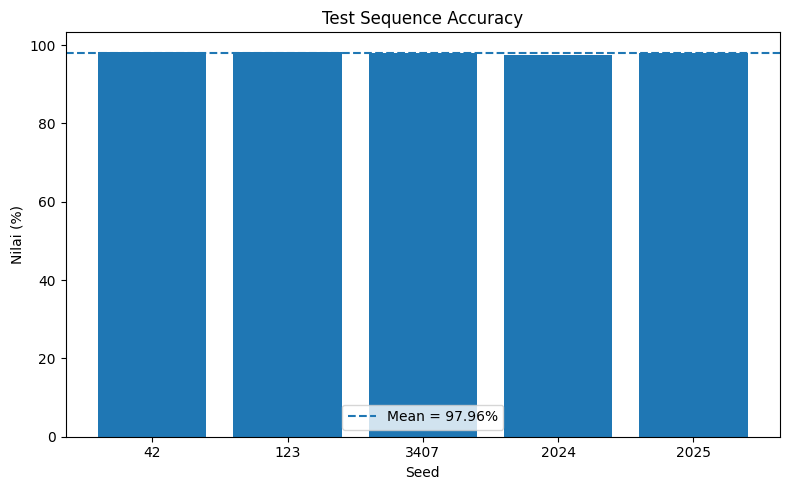

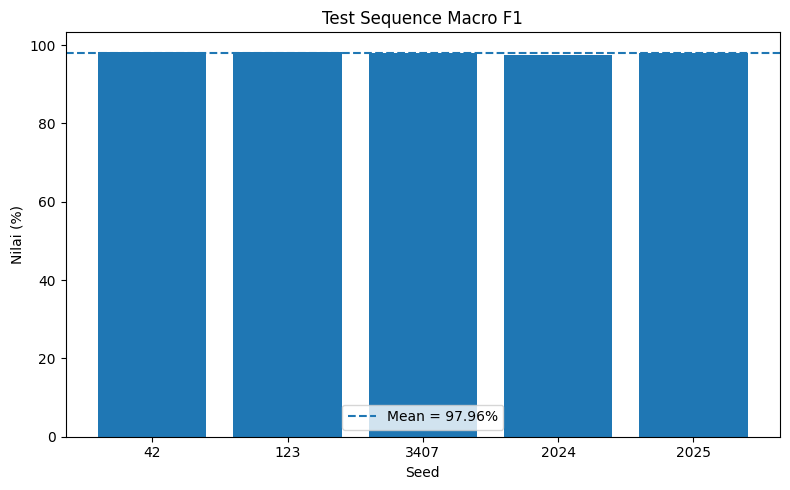

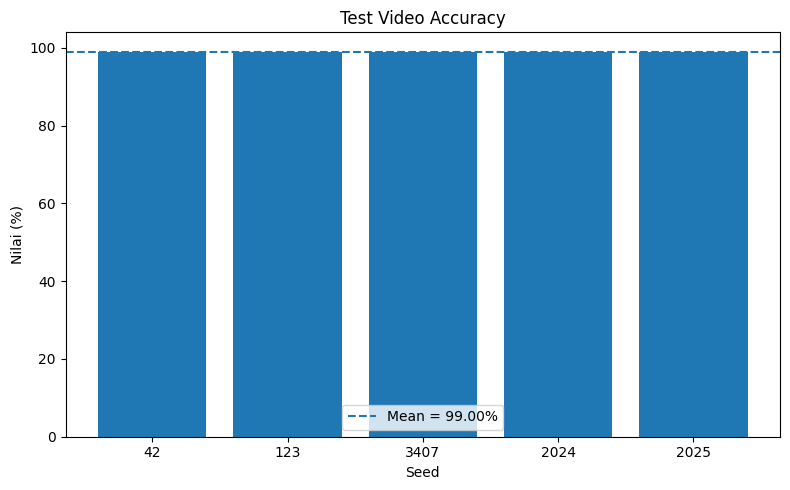

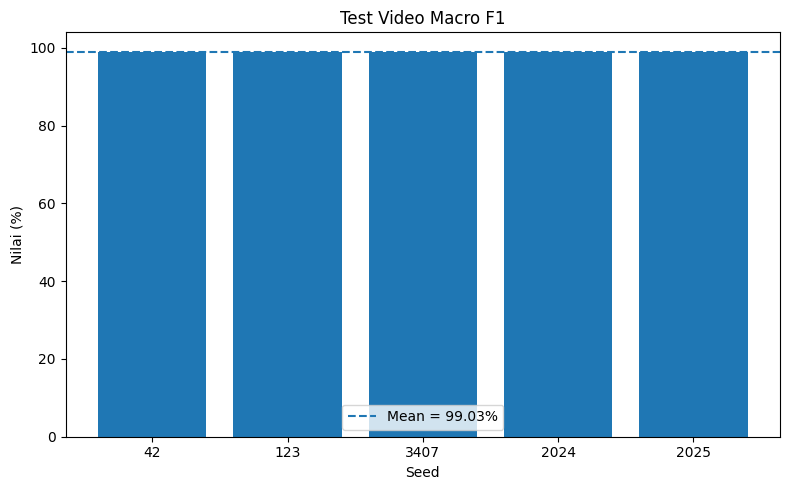

In [20]:
plot_metrics = [
    "test_sequence_accuracy",
    "test_sequence_macro_f1",
    "test_video_accuracy",
    "test_video_macro_f1",
]

for metric in plot_metrics:
    plt.figure(figsize=(8, 5))

    plt.bar(
        per_seed_df["seed"].astype(str),
        per_seed_df[metric] * 100.0,
    )

    mean_value = (
        per_seed_df[metric].mean() * 100.0
    )

    plt.axhline(
        mean_value,
        linestyle="--",
        label=f"Mean = {mean_value:.2f}%",
    )

    plt.xlabel("Seed")
    plt.ylabel("Nilai (%)")
    plt.title(
        metric.replace("_", " ").title()
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / f"{metric}_per_seed.png",
        dpi=180,
    )
    plt.show()


## 19. Pilih model representatif berdasarkan validation Macro F1


In [21]:
# Pemilihan model representatif hanya menggunakan validation,
# bukan test set. Mean ± std tetap dihitung dari seluruh seed.
representative_result = max(
    all_seed_results,
    key=lambda result: (
        result["validation_sequence"]["macro_f1"]
    ),
)

REPRESENTATIVE_SEED = representative_result["seed"]

print("Representative seed:", REPRESENTATIVE_SEED)
print(
    "Validation sequence Macro F1:",
    representative_result[
        "validation_sequence"
    ]["macro_f1"],
)

representative_checkpoint = (
    representative_result["model_dir"]
    / "best_model.pt"
)

shutil.copy2(
    representative_checkpoint,
    MODEL_DIR / "best_model_representative.pt",
)

with (
    REPORT_DIR / "representative_seed.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "representative_seed": REPRESENTATIVE_SEED,
            "selection_basis": (
                "highest validation sequence Macro F1"
            ),
            "validation_sequence": (
                representative_result[
                    "validation_sequence"
                ]
            ),
            "test_sequence": (
                representative_result[
                    "test_sequence"
                ]
            ),
            "validation_video": (
                representative_result[
                    "validation_video"
                ]
            ),
            "test_video": (
                representative_result[
                    "test_video"
                ]
            ),
        },
        file,
        indent=2,
        ensure_ascii=False,
    )


Representative seed: 3407
Validation sequence Macro F1: 0.9858382541231462


## Evaluasi Prediksi Sebelum 30 Frame

Training menggunakan beberapa panjang prefix, tetapi implementasi tidak boleh asal memilih angka 8 atau 12. Sel berikut menguji semua kandidat pada validation set, memilih prefix paling pendek yang masih mencapai minimal 90% Macro F1 dari window penuh dan coverage 80%, kemudian sekali menguji pilihan itu pada test set.


In [22]:
@torch.inference_mode()
def evaluate_prefix_length(
    model,
    indices,
    prefix_length,
):
    """
    Menguji model seolah-olah baru menerima beberapa frame awal.

    Sisa frame tetap berukuran sampai 30, tetapi diisi nol dan mask=False.
    Cara ini sama dengan yang nanti dilakukan pada implementasi real-time.
    """
    model.eval()
    indices = np.asarray(indices, dtype=np.int64)

    all_true = []
    all_pred = []
    used_samples = 0

    for start in range(0, len(indices), BATCH_SIZE):
        batch_indices = indices[start:start + BATCH_SIZE]
        batch_x = X_body110[batch_indices].copy()
        batch_mask = valid_masks[batch_indices].copy()

        batch_x[:, prefix_length:] = 0.0
        batch_mask[:, prefix_length:] = False

        enough_pose = (
            batch_mask.sum(axis=1)
            >= MIN_VALID_FRAMES_FOR_PARTIAL
        )
        if not np.any(enough_pose):
            continue

        batch_x = batch_x[enough_pose]
        batch_mask = batch_mask[enough_pose]
        batch_true = y[batch_indices][enough_pose]

        logits = model(
            torch.from_numpy(batch_x).to(DEVICE),
            torch.from_numpy(batch_mask).to(DEVICE),
        )
        prediction = logits.argmax(dim=1).cpu().numpy()

        all_true.extend(batch_true.tolist())
        all_pred.extend(prediction.tolist())
        used_samples += len(batch_true)

    if used_samples == 0:
        return {
            "prefix_frames": int(prefix_length),
            "prefix_seconds_at_30_fps": float(prefix_length / TARGET_FPS),
            "samples": 0,
            "coverage": 0.0,
            "accuracy": None,
            "macro_f1": None,
        }

    metrics = calculate_metrics(
        np.asarray(all_true, dtype=np.int64),
        np.asarray(all_pred, dtype=np.int64),
    )
    return {
        "prefix_frames": int(prefix_length),
        "prefix_seconds_at_30_fps": float(prefix_length / TARGET_FPS),
        "samples": int(used_samples),
        "coverage": float(used_samples / len(indices)),
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
    }


representative_model = representative_result["model"]

# Pemilihan jumlah frame minimum hanya memakai validation set.
validation_prefix_rows = [
    evaluate_prefix_length(
        representative_model,
        val_idx,
        prefix_length,
    )
    for prefix_length in PREFIX_EVAL_LENGTHS
]
validation_prefix_df = pd.DataFrame(validation_prefix_rows)

full_row = validation_prefix_df[
    validation_prefix_df["prefix_frames"] == WINDOW_SIZE
].iloc[0]
required_macro_f1 = float(
    full_row["macro_f1"] * PREFIX_MIN_F1_RATIO
)

eligible = validation_prefix_df[
    (validation_prefix_df["macro_f1"] >= required_macro_f1)
    & (validation_prefix_df["coverage"] >= PREFIX_MIN_COVERAGE)
]

if eligible.empty:
    RECOMMENDED_PREFIX_LENGTH = WINDOW_SIZE
else:
    RECOMMENDED_PREFIX_LENGTH = int(
        eligible.sort_values("prefix_frames").iloc[0]["prefix_frames"]
    )

# Test set baru dibuka setelah panjang prefix dipilih dari validation.
test_prefix_result = evaluate_prefix_length(
    representative_model,
    test_idx,
    RECOMMENDED_PREFIX_LENGTH,
)

validation_prefix_df.to_csv(
    REPORT_DIR / "validation_prefix_evaluation.csv",
    index=False,
)
pd.DataFrame([test_prefix_result]).to_csv(
    REPORT_DIR / "test_recommended_prefix_evaluation.csv",
    index=False,
)

prefix_summary = {
    "selection_uses_test": False,
    "candidate_prefix_lengths": list(PREFIX_EVAL_LENGTHS),
    "minimum_valid_frames": MIN_VALID_FRAMES_FOR_PARTIAL,
    "required_ratio_from_full_validation_macro_f1": PREFIX_MIN_F1_RATIO,
    "minimum_validation_coverage": PREFIX_MIN_COVERAGE,
    "recommended_prefix_length": RECOMMENDED_PREFIX_LENGTH,
    "recommended_prefix_seconds_at_30_fps": (
        RECOMMENDED_PREFIX_LENGTH / TARGET_FPS
    ),
    "validation_results": validation_prefix_rows,
    "test_result_at_recommended_prefix": test_prefix_result,
}

with (REPORT_DIR / "prefix_evaluation_summary.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(prefix_summary, file, indent=2, ensure_ascii=False)

display(validation_prefix_df)
print("Recommended minimum prefix:", RECOMMENDED_PREFIX_LENGTH, "frame")
print("Test result at recommended prefix:", test_prefix_result)


,prefix_frames,prefix_seconds_at_30_fps,samples,coverage,accuracy,macro_f1
0,8,0.266667,4010,0.994051,0.948379,0.948088
1,12,0.400000,4020,0.996529,0.963930,0.963773
2,16,0.533333,4022,0.997025,0.972153,0.972053
3,20,0.666667,4025,0.997769,0.974658,0.974524
4,24,0.800000,4033,0.999752,0.981155,0.981100
5,30,1.000000,4034,1.000000,0.985870,0.985838


Recommended minimum prefix: 8 frame
Test result at recommended prefix: {'prefix_frames': 8, 'prefix_seconds_at_30_fps': 0.26666666666666666, 'samples': 2769, 'coverage': 0.9967602591792657, 'accuracy': 0.9382448537378115, 'macro_f1': 0.93818132945959}


## 20. Ekspor ONNX model representatif dan validasi


In [23]:
model = representative_result["model"]

model_cpu = copy.deepcopy(
    model
).cpu().eval()

dummy_x = torch.zeros(
    1,
    WINDOW_SIZE,
    BODY110_DIM,
    dtype=torch.float32,
)

dummy_mask = torch.ones(
    1,
    WINDOW_SIZE,
    dtype=torch.bool,
)

ONNX_PATH = (
    MODEL_DIR
    / "har_window_30_representative.onnx"
)

torch.onnx.export(
    model_cpu,
    (
        dummy_x,
        dummy_mask,
    ),
    str(ONNX_PATH),
    input_names=[
        "input",
        "frame_mask",
    ],
    output_names=[
        "logits",
    ],
    dynamic_axes={
        "input": {0: "batch"},
        "frame_mask": {0: "batch"},
        "logits": {0: "batch"},
    },
    opset_version=17,
    dynamo=False,
)

session = ort.InferenceSession(
    str(ONNX_PATH),
    providers=["CPUExecutionProvider"],
)

sample_indices = val_idx[
    :min(128, len(val_idx))
]

sample_x = X_body110[
    sample_indices
].astype(np.float32)

sample_mask = valid_masks[
    sample_indices
].astype(np.bool_)

with torch.inference_mode():
    pytorch_logits = model_cpu(
        torch.from_numpy(sample_x),
        torch.from_numpy(sample_mask),
    ).numpy()

onnx_logits = session.run(
    None,
    {
        session.get_inputs()[0].name: sample_x,
        session.get_inputs()[1].name: sample_mask,
    },
)[0]

max_difference = float(
    np.max(
        np.abs(
            pytorch_logits - onnx_logits
        )
    )
)

agreement = float(
    np.mean(
        pytorch_logits.argmax(axis=1)
        == onnx_logits.argmax(axis=1)
    )
)

print("ONNX max difference:", max_difference)
print("PyTorch–ONNX agreement:", agreement)

if agreement < 1.0:
    raise RuntimeError(
        "Prediksi PyTorch dan ONNX tidak sama."
    )


/tmp/ipykernel_22/198714781.py:25: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4445: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


ONNX max difference: 2.384185791015625e-06
PyTorch–ONNX agreement: 1.0


## 21. Metadata eksperimen lima seed


In [24]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as file:
        while True:
            block = file.read(1024 * 1024)

            if not block:
                break

            digest.update(block)

    return digest.hexdigest()


metadata = {
    "pipeline": (
        "detector_crop_yolo26pose_"
        "framexy_body110_cnn_bilstm"
    ),
    "feature_version": "body110",
    "feature_dim": BODY110_DIM,
    "window_size": WINDOW_SIZE,
    "class_names": class_names,
    "seeds": SEEDS,
    "number_of_runs": len(SEEDS),
    "standard_deviation": "sample_std_ddof_1",
    "model_selection_uses_test": False,
    "train_sequences_per_epoch": int(
        len(train_dataset)
    ),
    "uses_all_train_sequences": True,
    "partial_prefix_augmentation": USE_PARTIAL_PREFIX_AUGMENTATION,
    "partial_prefix_probability": PARTIAL_PREFIX_PROBABILITY,
    "partial_prefix_lengths": list(PARTIAL_PREFIX_LENGTHS),
    "recommended_prefix_length": RECOMMENDED_PREFIX_LENGTH,
    "recommended_prefix_seconds_at_30_fps": (
        RECOMMENDED_PREFIX_LENGTH / TARGET_FPS
    ),
    "selection_metric_per_run": (
        "validation_macro_f1"
    ),
    "representative_seed": REPRESENTATIVE_SEED,
    "representative_selection": (
        "highest validation sequence Macro F1"
    ),
    "pytorch_onnx_max_difference": (
        max_difference
    ),
    "pytorch_onnx_agreement": agreement,
    "onnx_sha256": sha256(ONNX_PATH),
    "preprocessed_root": str(
        PREPROCESSED_ROOT
    ),
    "mean_std_results": mean_std_df.to_dict(
        orient="records"
    ),
}

with (
    MODEL_DIR / "pipeline_metadata.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(
    json.dumps(
        metadata,
        indent=2,
        ensure_ascii=False,
    )
)


{
  "pipeline": "detector_crop_yolo26pose_framexy_body110_cnn_bilstm",
  "feature_version": "body110",
  "feature_dim": 110,
  "window_size": 30,
  "class_names": [
    "boxing",
    "carrying",
    "clapping",
    "digging",
    "jogging",
    "running",
    "throwing",
    "walking",
    "waving"
  ],
  "seeds": [
    42,
    123,
    3407,
    2024,
    2025
  ],
  "number_of_runs": 5,
  "standard_deviation": "sample_std_ddof_1",
  "model_selection_uses_test": false,
  "train_sequences_per_epoch": 20629,
  "uses_all_train_sequences": true,
  "partial_prefix_augmentation": true,
  "partial_prefix_probability": 0.5,
  "partial_prefix_lengths": [
    8,
    12,
    16,
    20,
    24,
    30
  ],
  "recommended_prefix_length": 8,
  "recommended_prefix_seconds_at_30_fps": 0.26666666666666666,
  "selection_metric_per_run": "validation_macro_f1",
  "representative_seed": 3407,
  "representative_selection": "highest validation sequence Macro F1",
  "pytorch_onnx_max_difference": 2.38418579

## 22. ZIP seluruh hasil


In [25]:
zip_path = shutil.make_archive(
    str(OUTPUT_ROOT),
    "zip",
    root_dir=OUTPUT_ROOT,
)

print("Eksperimen lima seed selesai.")
print("ZIP:", zip_path)
print()
print("Hasil utama:")
print(
    REPORT_DIR / "five_seed_results.csv"
)
print(
    REPORT_DIR / "five_seed_mean_std.csv"
)
print(
    REPORT_DIR / "five_seed_summary.json"
)
print()
print("Model representatif:")
print(
    MODEL_DIR / "best_model_representative.pt"
)
print(
    MODEL_DIR / "har_window_30_representative.onnx"
)
print(
    MODEL_DIR / "pipeline_metadata.json"
)


Eksperimen lima seed selesai.
ZIP: /kaggle/working/TRAINING_FINAL_BODY110_SEEDS_42_123_3407_2024_2025.zip

Hasil utama:
/kaggle/working/TRAINING_FINAL_BODY110_SEEDS_42_123_3407_2024_2025/reports/five_seed_results.csv
/kaggle/working/TRAINING_FINAL_BODY110_SEEDS_42_123_3407_2024_2025/reports/five_seed_mean_std.csv
/kaggle/working/TRAINING_FINAL_BODY110_SEEDS_42_123_3407_2024_2025/reports/five_seed_summary.json

Model representatif:
/kaggle/working/TRAINING_FINAL_BODY110_SEEDS_42_123_3407_2024_2025/models/best_model_representative.pt
/kaggle/working/TRAINING_FINAL_BODY110_SEEDS_42_123_3407_2024_2025/models/har_window_30_representative.onnx
/kaggle/working/TRAINING_FINAL_BODY110_SEEDS_42_123_3407_2024_2025/models/pipeline_metadata.json
